In [44]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,precision_score,recall_score,f1_score
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
plt.rcParams["font.family"]="Times new roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

In [24]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

In [25]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [26]:
print(x_train[0].shape)

(32, 32, 3)


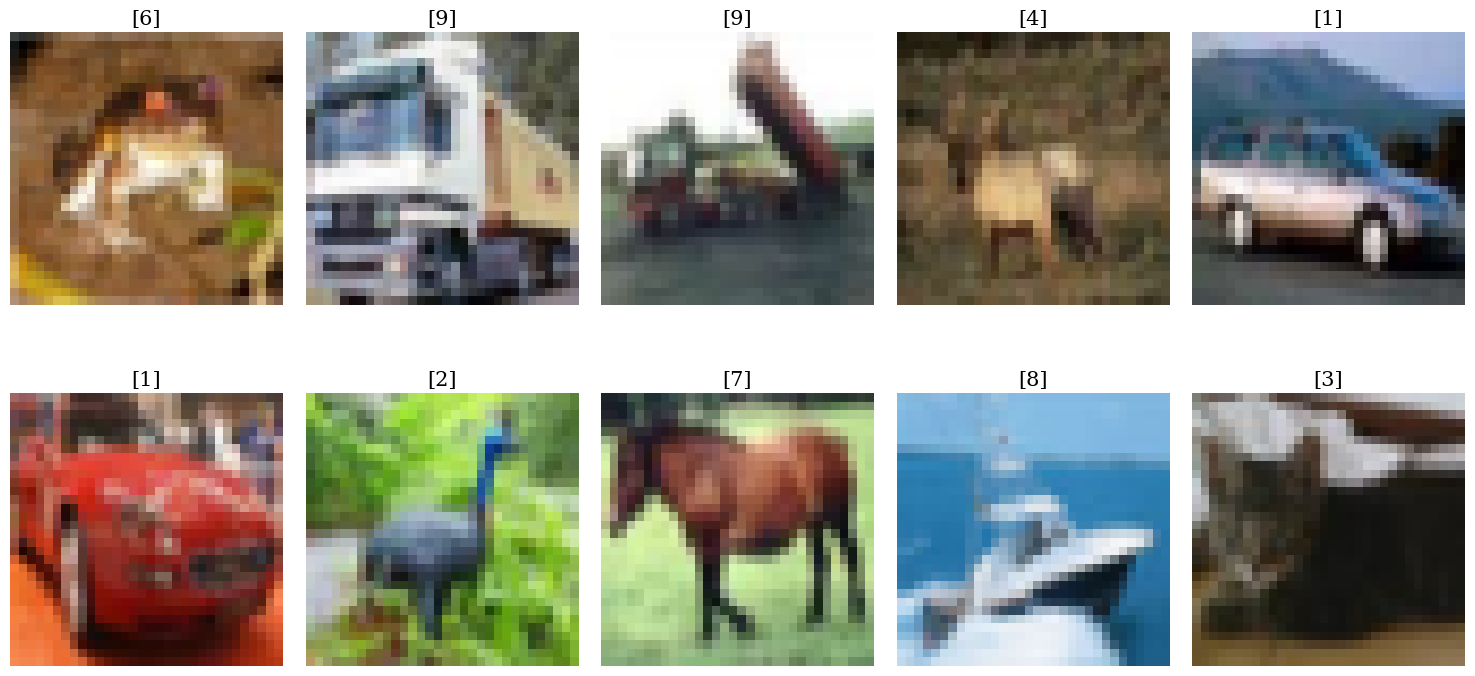

In [27]:
plt.figure(figsize=(15,8))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(y_train[i])
  plt.axis("off")
plt.tight_layout()
plt.savefig("images/sample_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [28]:
print(x_train.min())
print(x_train.max())

0
255


In [29]:
print(x_train[0][0][0])

[59 62 63]


In [30]:
x_train=x_train/255
x_test=x_test/255

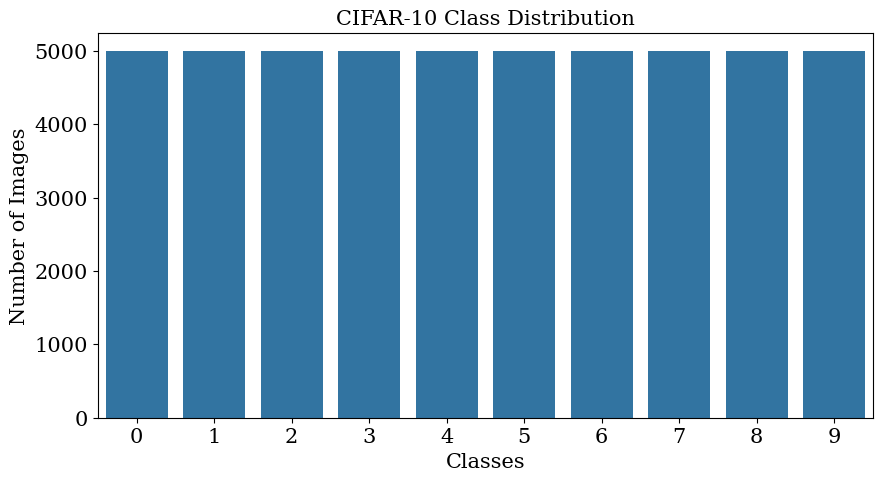

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(x=y_train.flatten(),)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")
plt.savefig("images/class_distribution.eps",format="eps",dpi=600,bbox_inches="tight")

plt.show()

In [32]:
model=Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3)
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3810 - loss: 1.6896 - val_accuracy: 0.5241 - val_loss: 1.3416
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5040 - loss: 1.3763 - val_accuracy: 0.5833 - val_loss: 1.1920
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5578 - loss: 1.2388 - val_accuracy: 0.6205 - val_loss: 1.0812
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5938 - loss: 1.1438 - val_accuracy: 0.6519 - val_loss: 1.0049
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6189 - loss: 1.0726 - val_accuracy: 0.6500 - val_loss: 0.9804
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6375 - loss: 1.0237 - val_accuracy: 0.6764 - val_loss: 0.9269
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6543 - loss: 0.9791 - val_accuracy: 0.6806 - val_loss: 0.9238
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6711 - loss: 0.9294 - val_accuracy: 0.

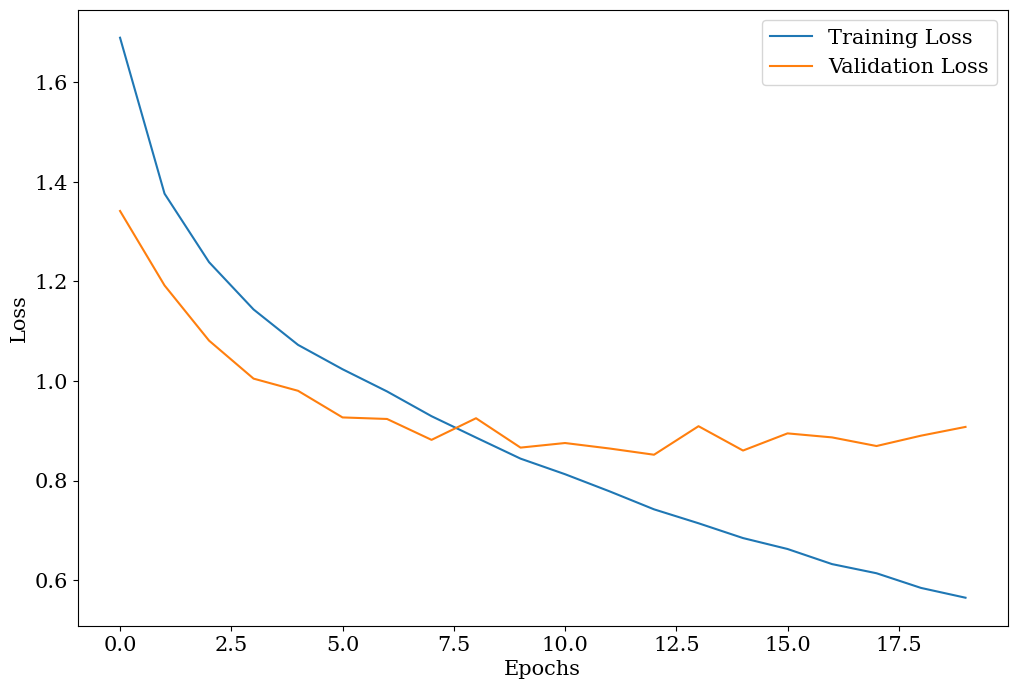

In [36]:
plt.figure(figsize=(12,8))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.savefig("images/loss_curve.eps",format="eps",dpi=600,bbox_inches="tight")
plt.legend()

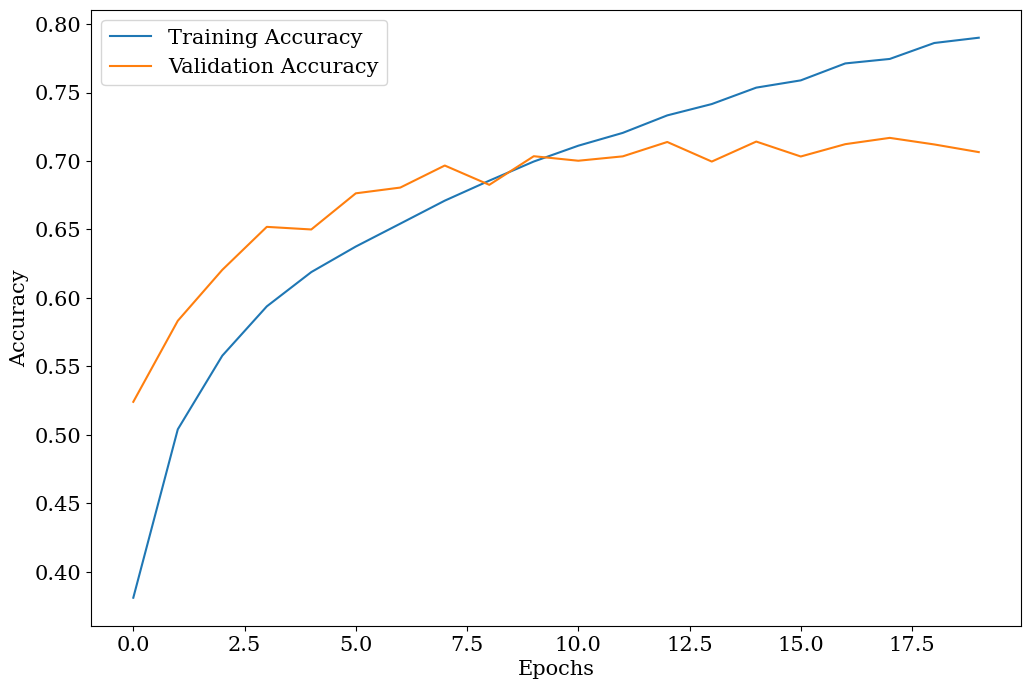

In [37]:
plt.figure(figsize=(12,8))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.savefig("images/accuracy_curve.eps",format="eps",dpi=600,bbox_inches="tight")
plt.legend()

In [38]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)

print("Test Accuracy:",test_accuracy)
print("Test Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7101 - loss: 0.9060
Test Accuracy: 0.710099995136261
Test Loss: 0.9059980511665344


In [39]:
y_pred=model.predict(x_test)
print("Accuracy score: ",accuracy_score(y_test,np.argmax(y_pred,axis=1)))
print("precision score: ",precision_score(y_test,np.argmax(y_pred,axis=1),average="macro"))
print("recall score: ",recall_score(y_test,np.argmax(y_pred,axis=1),average="macro"))
print("f1 score: ",f1_score(y_test,np.argmax(y_pred,axis=1),average="macro"))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy score:  0.7101
precision score:  0.7182130743602934
recall score:  0.7101
f1 score:  0.7118567024381257


confusion matrix


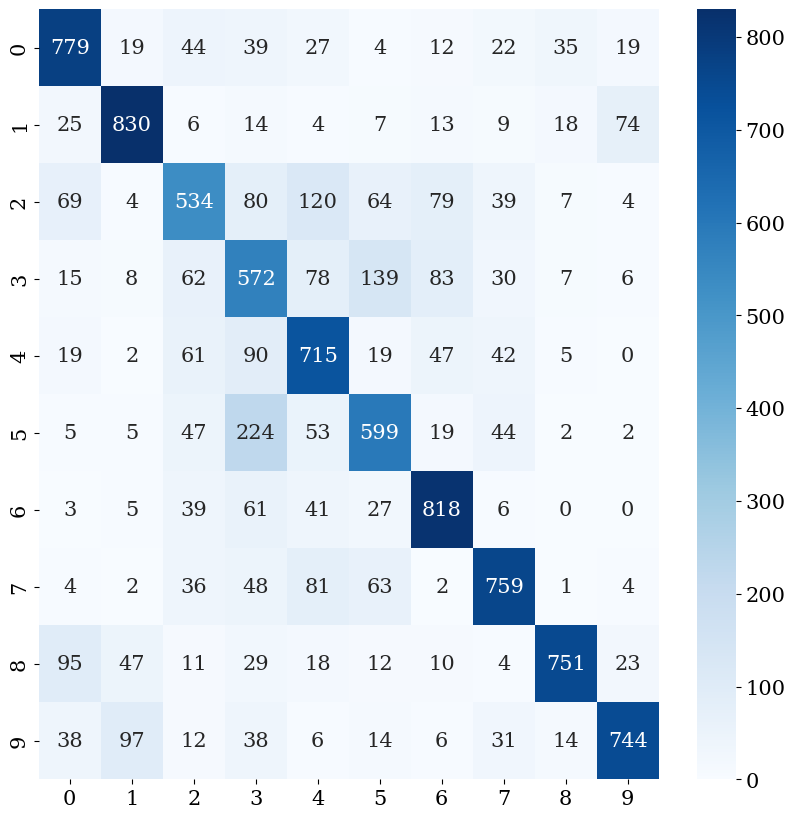

In [40]:
print("confusion matrix")
plt.figure(figsize=(10,10))
sns.heatmap(confusion_matrix(y_test,np.argmax(y_pred,axis=1)),annot=True,fmt="d",cmap="Blues")
plt.savefig("images/confusion_matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [41]:
print(classification_report(y_test,np.argmax(y_pred,axis=1)))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1000
           1       0.81      0.83      0.82      1000
           2       0.63      0.53      0.58      1000
           3       0.48      0.57      0.52      1000
           4       0.63      0.71      0.67      1000
           5       0.63      0.60      0.61      1000
           6       0.75      0.82      0.78      1000
           7       0.77      0.76      0.76      1000
           8       0.89      0.75      0.82      1000
           9       0.85      0.74      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



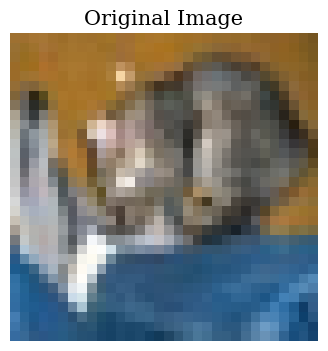

Number of convolutional layers: 2
Feature map shape after Conv2D layer 1 : (32, 32, 32)


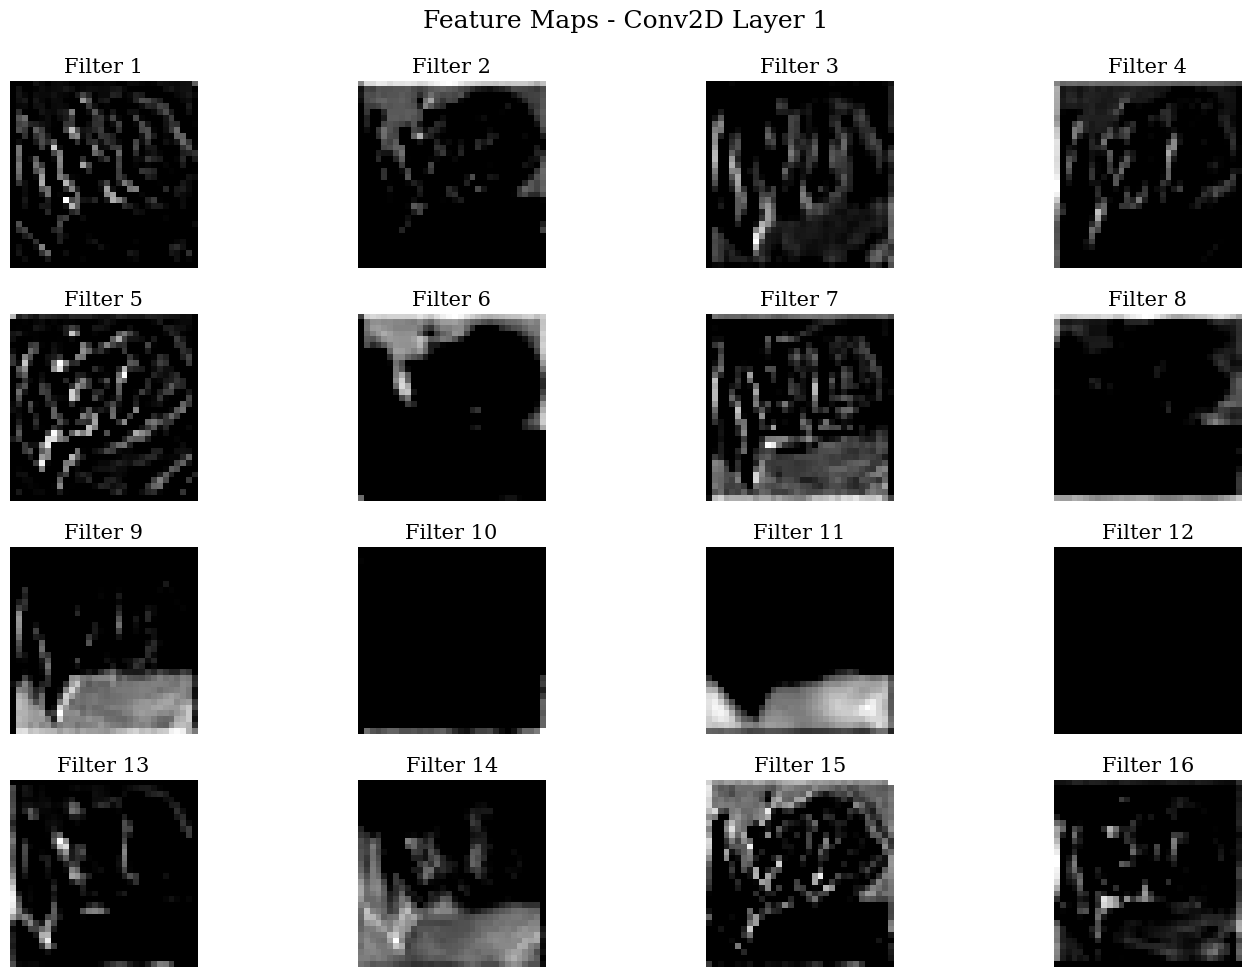

Feature map shape after Conv2D layer 2 : (16, 16, 64)


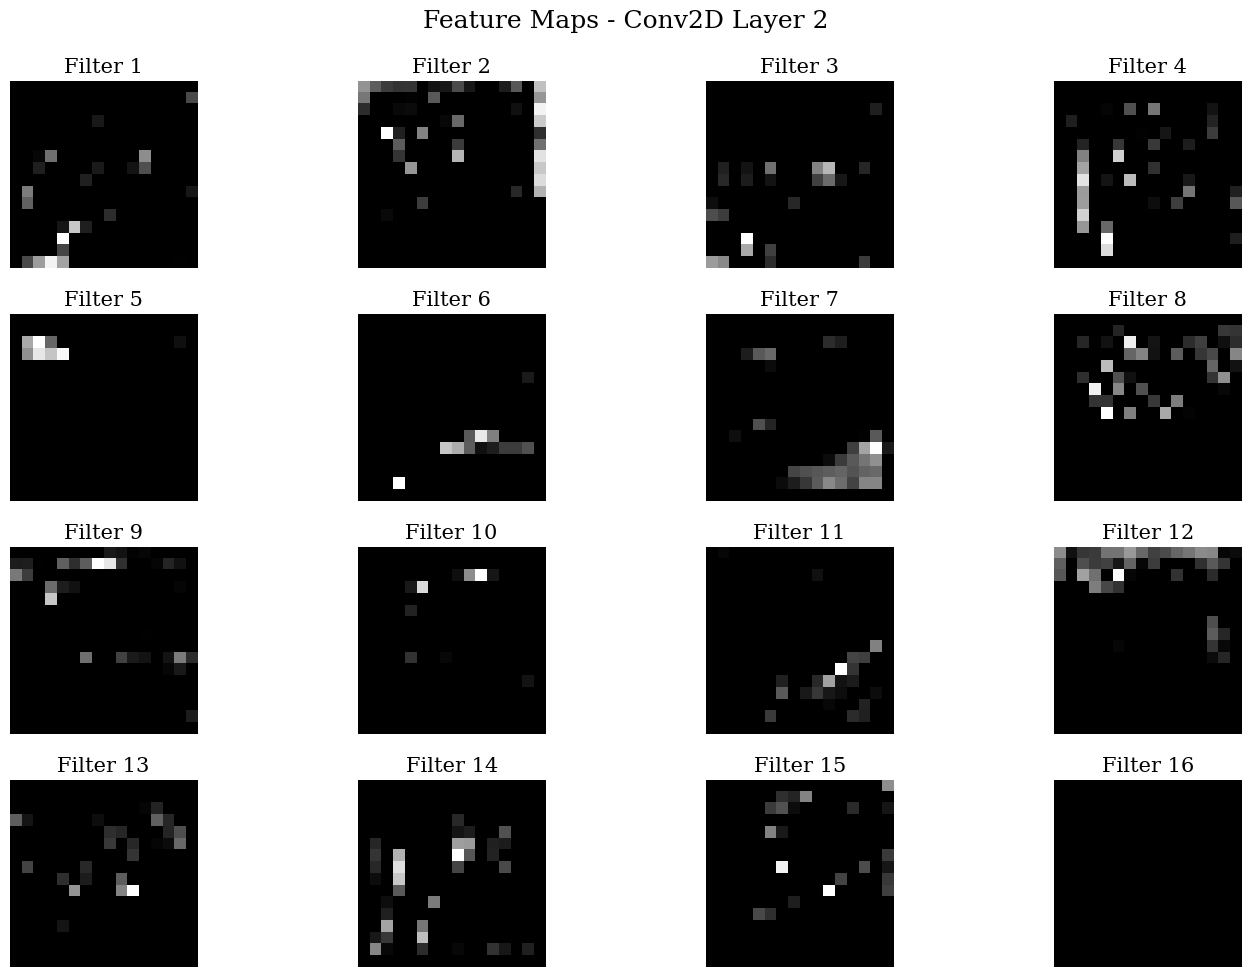

In [43]:
sample_image=x_test[0]

plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

conv_layers=[layer for layer in model.layers if isinstance(layer, Conv2D)]

print("Number of convolutional layers:", len(conv_layers))

feature_model=Model(
    inputs=model.layers[0].input,
    outputs=[layer.output for layer in conv_layers]
)

feature_maps=feature_model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)

for i,fmap in enumerate(feature_maps):
    fmap=fmap[0]
    print("Feature map shape after Conv2D layer",i+1,":",fmap.shape)
    plt.figure(figsize=(15,10))
    num_features = min(fmap.shape[-1], 16)
    for j in range(num_features):
        plt.subplot(4,4,j+1)
        plt.imshow(fmap[:,:,j], cmap="gray")
        plt.title("Filter " + str(j+1))
        plt.axis("off")

    plt.suptitle("Feature Maps - Conv2D Layer " + str(i+1))
    plt.tight_layout()
    plt.savefig(
        "images/feature_maps_conv" + str(i+1) + ".eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

In [45]:
average_model=Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        padding="same",
        activation="relu",
        input_shape=(32,32,3)
    ),
    AveragePooling2D(pool_size=(2,2)),
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        strides=(1,1),
        padding="same",
        activation="relu"
    ),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

average_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
average_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
average_history=average_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3801 - loss: 1.7117 - val_accuracy: 0.5047 - val_loss: 1.4078
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4912 - loss: 1.4149 - val_accuracy: 0.5679 - val_loss: 1.2273
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5386 - loss: 1.2964 - val_accuracy: 0.5935 - val_loss: 1.1512
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5685 - loss: 1.2119 - val_accuracy: 0.6211 - val_loss: 1.0836
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5954 - loss: 1.1455 - val_accuracy: 0.6432 - val_loss: 1.0267
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6131 - loss: 1.0899 - val_accuracy: 0.6521 - val_loss: 0.9947
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6333 - loss: 1.0449 - val_accuracy: 0.6633 - val_loss: 0.9739
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6478 - loss: 0.9971 - val_accuracy: 0.

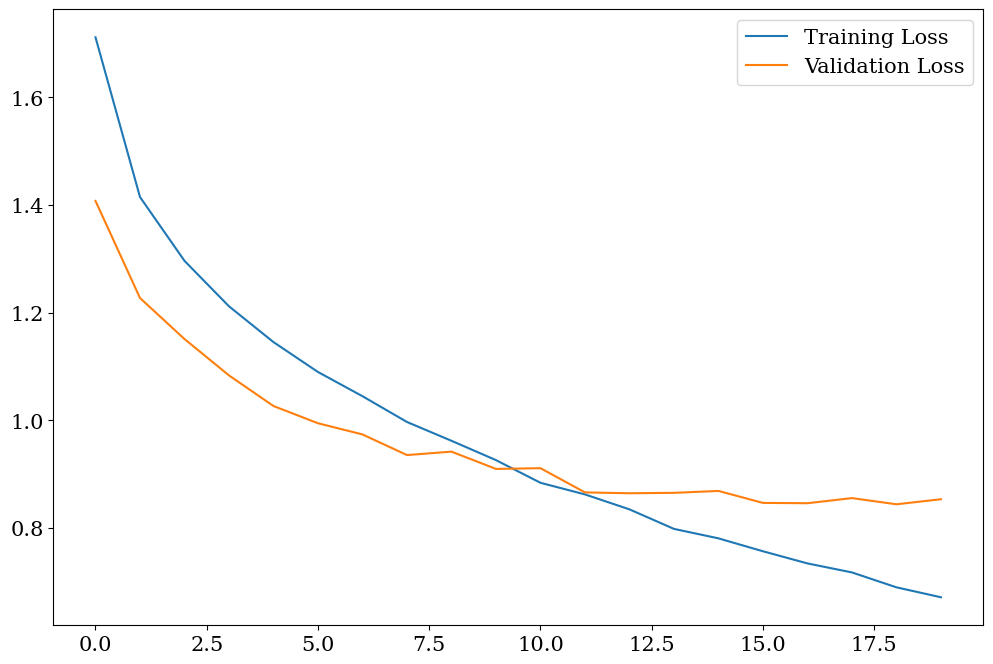

In [53]:
plt.figure(figsize=(12,8))
plt.plot(average_history.history["loss"],label="Training Loss")
plt.plot(average_history.history["val_loss"],label="Validation Loss")
plt.legend()

plt.savefig(
    "images/average_pooling_loss_curve.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

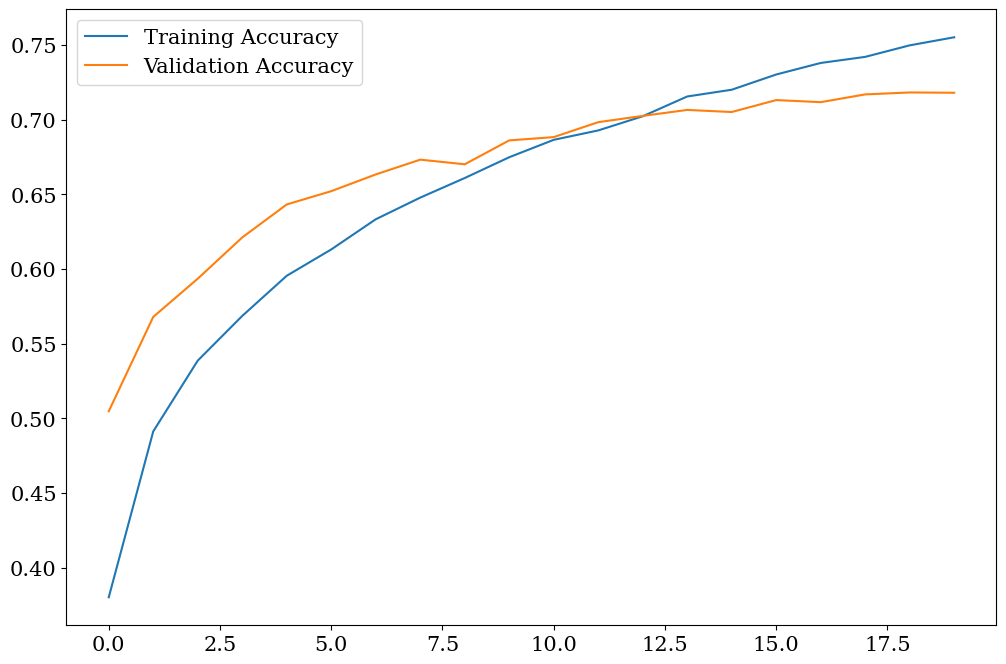

In [54]:
plt.figure(figsize=(12,8))
plt.plot(average_history.history["accuracy"],label="Training Accuracy")
plt.plot(average_history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()

plt.savefig(
    "images/average_pooling_accuracy_curve.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [48]:
average_test_loss,average_test_accuracy=average_model.evaluate(x_test,y_test)

print("Average Pooling Test Accuracy:",average_test_accuracy)
print("Average Pooling Test Loss:",average_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7102 - loss: 0.8631
Average Pooling Test Accuracy: 0.7102000117301941
Average Pooling Test Loss: 0.8631484508514404


In [49]:
average_y_pred=average_model.predict(x_test)
average_y_pred_classes=np.argmax(average_y_pred,axis=1)
print("Accuracy score: ",accuracy_score(y_test,average_y_pred_classes))
print("Precision score: ",precision_score(y_test,average_y_pred_classes,average="macro"))
print("Recall score: ",recall_score(y_test,average_y_pred_classes,average="macro"))
print("F1 score: ",f1_score(y_test,average_y_pred_classes,average="macro"))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Accuracy score:  0.7102
Precision score:  0.7091765010337954
Recall score:  0.7101999999999999
F1 score:  0.7079680814601003


In [50]:
print("Classification Report")
print(classification_report(y_test,average_y_pred_classes))

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.79      0.76      1000
           1       0.83      0.82      0.83      1000
           2       0.58      0.62      0.60      1000
           3       0.54      0.47      0.50      1000
           4       0.68      0.62      0.65      1000
           5       0.66      0.58      0.61      1000
           6       0.70      0.83      0.76      1000
           7       0.73      0.80      0.76      1000
           8       0.85      0.79      0.82      1000
           9       0.79      0.78      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



Confusion Matrix


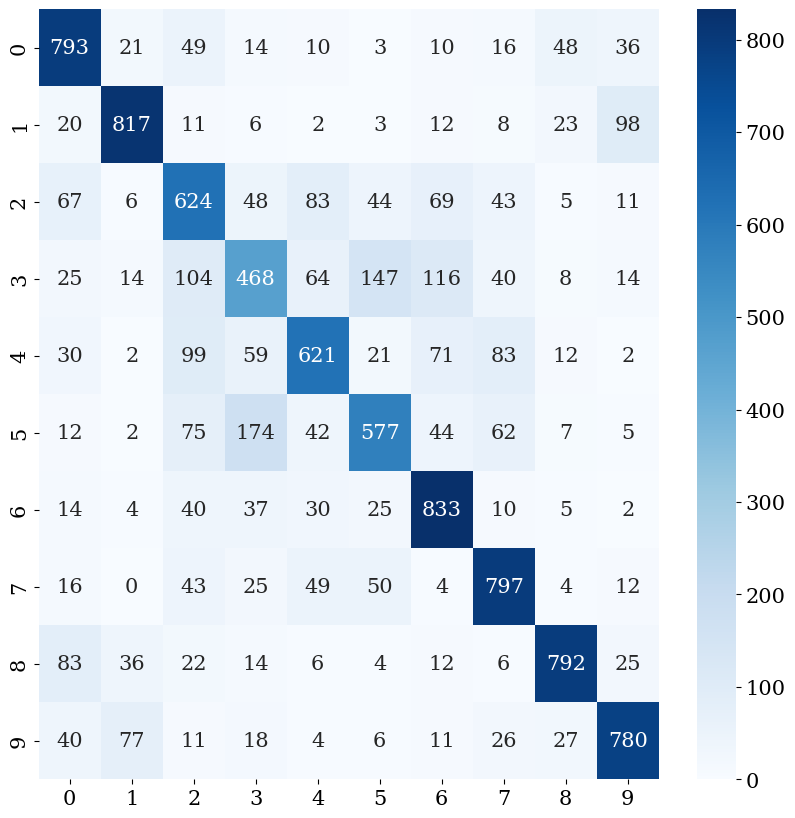

In [51]:
print("Confusion Matrix")
plt.figure(figsize=(10,10))
sns.heatmap(confusion_matrix(y_test,average_y_pred_classes),annot=True,fmt="d",cmap="Blues")

plt.savefig(
    "images/average_pooling_confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [52]:
print("Max Pooling Test Accuracy:",test_accuracy)
print("Average Pooling Test Accuracy:",average_test_accuracy)

print("Max Pooling Test Loss:",test_loss)
print("Average Pooling Test Loss:",average_test_loss)

Max Pooling Test Accuracy: 0.710099995136261
Average Pooling Test Accuracy: 0.7102000117301941
Max Pooling Test Loss: 0.9059980511665344
Average Pooling Test Loss: 0.8631484508514404
